In [ ]:
import astropy
from astropy.io import fits
import bagpipes as pipes
import pathlib
import os
import numpy as np

In [ ]:
JADES_File_Path = pathlib.Path('../JADES/catalogs').expanduser()

In [ ]:
for file in JADES_File_Path.glob('*.fits'):
    with astropy.io.fits.open(file) as hdul:
        data = hdul[5].data
        print(hdul.info())

In [ ]:
fits_path = '../JADES/catalogs/hlsp_jades_jwst_nircam_goods-n_photometry_v5.0_catalog.fits'

In [ ]:
import pandas as pd
with fits.open(fits_path) as hdul:
    data = hdul[5].data
    df = pd.DataFrame(data)
    print(df.columns)

In [ ]:
import os
from astropy.io import fits

# 1. 设置路径
filter_dir = "my_filters"
current_dir = os.getcwd()

# 2. 从 FITS 文件中获取原始波段顺序（非常重要，必须对应）
with fits.open(fits_path) as hdul:
    # 假设 hdul[1] 是滤光片信息表
    raw_filter_names = hdul[1].data["BAND"]
    # 转换为字符串并统一大写
    raw_filter_names = [str(n).upper() for n in raw_filter_names]

# 3. 扫描本地文件夹，只保留下载成功的滤光片
valid_filter_names = []
valid_filter_paths = []

print("正在同步本地滤光片文件...")

for name in raw_filter_names:
    # 检查本地是否存在对应的 .res 文件
    res_file = f"{name}.res"
    res_path = os.path.join(current_dir, filter_dir, res_file)

    if os.path.exists(res_path):
        valid_filter_names.append(name)
        valid_filter_paths.append(res_path)
        print(f"✅ 已加载本地文件: {res_file}")
    else:
        # 这些通常是之前下载失败的 HST 波段或特殊波段
        print(f"⚠️ 跳过(本地无文件): {name}")

print(f"\n同步完成！共计 {len(valid_filter_names)} 个有效滤光片。")
print(f"有效列表名称: {valid_filter_names}")

In [ ]:
import os
from astropy.io import fits

filter_dir = "my_filters"
current_dir = os.getcwd()

# 1. 获取 FITS 表中所有的列名
with fits.open(fits_path) as hdul:
    all_columns = hdul[5].columns.names  # 获取所有列名
    raw_bands = hdul[1].data["BAND"]     # 获取原始波段名
    raw_bands = [str(n).upper() for n in raw_bands]

# 2. 重新生成有效清单
final_valid_names = []
final_valid_paths = []

print("正在严格对齐本地文件与 FITS 列名...")

for name in raw_bands:
    res_path = os.path.join(current_dir, filter_dir, f"{name}.res")

    # 检查 A: 本地是否有 .res 文件
    file_exists = os.path.exists(res_path)

    # 检查 B: FITS 表里是否有对应的 CIRC3 列
    # 如果是 MIRI 波段（F770W及以上），CIRC3 可能不存在，尝试匹配其他列
    circ_col = f"{name}_CIRC3"
    col_exists = circ_col in all_columns

    if file_exists and col_exists:
        final_valid_names.append(name)
        final_valid_paths.append(res_path)
        print(f"✅ 匹配成功: {name} (使用列 {circ_col})")
    elif file_exists and not col_exists:
        # 如果有文件但没 CIRC3，检查是否有基础 FLUX 列
        if f"{name}_FLUX" in all_columns:
            # 这里你可以决定是否使用基础 FLUX 列，或者干脆跳过
            # 建议跳过以保持所有波段孔径一致性
            print(f"⚠️ 跳过: {name} (本地有文件但表中无 _CIRC3 列)")
        else:
            print(f"❌ 跳过: {name} (表中完全找不到该波段数据)")
    else:
        print(f"⚠️ 跳过: {name} (本地无 .res 文件)")

print(f"\n对齐完成！最终参与拟合的波段数量: {len(final_valid_names)}")

In [ ]:
np.sum(z_mask)

In [91]:
from numpy import argsort


with fits.open(fits_path) as hdul:
    circ_data = hdul[5].data
    photoz_data = hdul[11].data

    # 1. 建立ID映射
    id_circ = circ_data["ID"].astype(int)
    id_photoz = photoz_data["ID"].astype(int)
    common_ids, idx_c, idx_p = np.intersect1d(id_circ, id_photoz, return_indices=True)

    # 2. 准备计算所有有效波段的 SNR
    # final_valid_names 是你之前对齐好的滤光片列表
    all_snrs = []
    for band in final_valid_names:
        f = circ_data[f"{band}_CIRC3"][idx_c]
        e = circ_data[f"{band}_CIRC3_e"][idx_c]
        all_snrs.append(f / (e + 1e-8))

    snr_array = np.array(all_snrs) # 形状: (波段数, 星系数)

    # 3. 筛选准则：
    # - 官方红移在 3 < z < 7 (确保 Lyman break 在观测范围内)
    # - 计算有多少个波段的 SNR > 15
    # - 计算这些波段的平均 SNR
    z_ml = photoz_data["z_ml"][idx_p]
    z_mask = (z_ml > 3) & (z_ml < 7)

    # 统计每个星系有多少个波段 SNR > 15
    high_snr_count = np.nansum(snr_array > 15, axis=0)
    # 计算所有波段的平均 SNR
    mean_snr = np.nansum(snr_array, axis=0) / 25

    # 综合评分：优先考虑高 SNR 波段数量多的，其次看平均 SNR
    score = high_snr_count * 10 + mean_snr

    # 在符合红移范围的星系中找分值最高的
    max_score_ids=np.sort(score[z_mask])
    ids=np.argsort(score[z_mask])[::-1]  # 获取分值最高的前5个星系的分数

    best_idx = ids[5600]

    target_id = int(common_ids[z_mask][best_idx])
    target_z = z_ml[z_mask][best_idx]

    print(f"🌟 找到多波段高质量星系 ID: {target_id}")
    print(f"📊 官方红移估算: {target_z:.3f}")
    print(f"🔥 SNR > 15 的波段数量: {high_snr_count[z_mask][best_idx]}")
    print(f"📈 平均信噪比: {mean_snr[z_mask][best_idx]:.2f}")



    # # 打印前 5 个 SNR 最好的波段
    # sorted_snr_indices = np.argsort(snr_array[:,z_mask][:, best_idx])[::-1]
    # print("各波段表现：")
    # for i in sorted_snr_indices[:5]:
    #     print(f"   {final_valid_names[i]}: SNR = {snr_array[:,z_mask][i, best_idx]:.2f}")

🌟 找到多波段高质量星系 ID: 1217948
📊 官方红移估算: 3.480
🔥 SNR > 15 的波段数量: 5
📈 平均信噪比: 9.19


In [92]:
def load_jades_multi_high(ID):
    # 提取数字 ID
    numeric_id = int(''.join(filter(str.isdigit, str(ID))))

    with fits.open(fits_path) as hdul:
        data = hdul[5].data
        ids_in_table = data["ID"].astype(int)
        idx = np.where(ids_in_table == numeric_id)[0][0]

        fluxes, errors = [], []
        for band in final_valid_names:
            col_f, col_e = f"{band}_CIRC3", f"{band}_CIRC3_e"

            # nJy -> uJy
            f_uJy = data[col_f][idx] / 1000.0
            e_uJy = data[col_e][idx] / 1000.0

            fluxes.append(f_uJy)

            errors.append(e_uJy)

    return np.c_[fluxes, errors]

In [93]:
raw_data=load_jades_multi_high(target_id)

In [94]:
filters=[]
filters_path=[]
for i, name in enumerate(final_valid_names):
    if raw_data[i,0] > 0 and raw_data[i,1] > 0:
        filters.append(name)
        filters_path.append(os.path.join(current_dir, filter_dir, f"{name}.res"))



In [95]:
def load_solid_filters(id):
    raw_data=load_jades_multi_high(id)
    flux,err=[],[]
    for i, name in enumerate(final_valid_names):
        if name in filters:
            flux.append(raw_data[i,0])
            err.append(raw_data[i,1]+0.05*raw_data[i,0])
    return np.c_[flux, err]
#extra 5% noise

In [96]:
load_solid_filters(target_id)

array([[0.30513966, 0.02264325],
       [0.35884938, 0.02372844],
       [0.04142815, 0.0103579 ],
       [0.12489577, 0.01236585],
       [0.17110907, 0.01590276],
       [0.17344779, 0.01622925],
       [0.17580436, 0.02058949],
       [0.16376427, 0.02125013],
       [0.20859009, 0.02520398],
       [0.2359187 , 0.02979234]], dtype=float32)

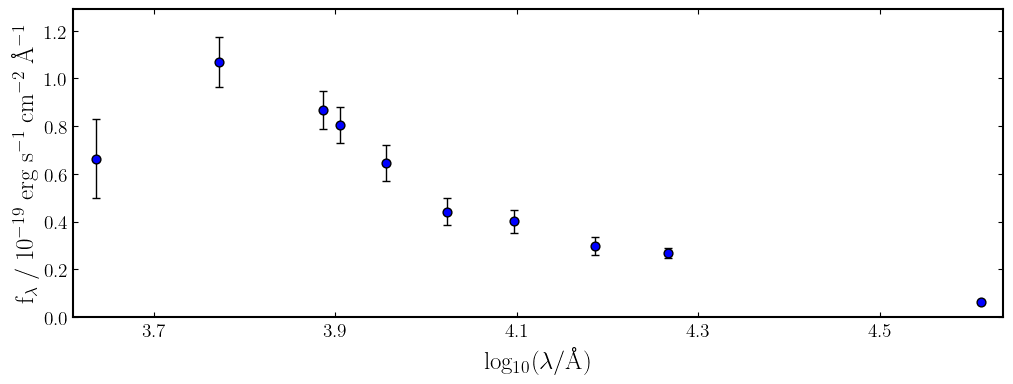

In [97]:
fit_id = f"{target_id}"

# 2. 初始化 Galaxy
galaxy = pipes.galaxy(fit_id, load_solid_filters,
                      spectrum_exists=False,
                      filt_list=filters_path,phot_units="mujy", out_units="ergscma")
fig=galaxy.plot()

In [98]:
redshift = target_z
from astropy.cosmology import Planck18 as cosmo

current_cosmic_age = cosmo.age(redshift).value  # 单位是 Gyr
max_age_form_stars=cosmo.age(redshift+0.3).value
max_age_form_stars

np.float64(1.6442056503821967)

In [99]:

fit_instructions = {
    "redshift": (redshift - 0.2, redshift + 0.2), #+-0.3
    "delayed": {
        "tau":(0.001, 1.),
        "age": (0.01, max_age_form_stars),
        "massformed": (0.1, 12.),
        "metallicity": (0., 1.5)
    }, #only delayed tau
    # "constant": {
    #     "age_max": (0.01, max_age_form_stars),
    #     "age_min": (0.01, max_age_form_stars),
    #     "massformed": (0.1, 12.),
    #     "metallicity": (0., 1.5)
    #     },
    # "burst":{
    #     "age": (0.01, max_age_form_stars),
    #     "massformed": (0.1, 12.),
    #     "metallicity": (0., 1.5)
    # },
    "dust": {"type": "Calzetti", "Av": (0., 2.0)},
    "nebular": {
        "logU": (-3, -1)
    }
}


fit = pipes.fit(galaxy, fit_instructions)
fit.fit(verbose=False)



Bagpipes: fitting object 1217948

 MultiNest Warning: no resume file found, starting from scratch
 *****************************************************
 MultiNest v3.10
 Copyright Farhan Feroz & Mike Hobson
 Release Jul 2015

 no. of live points =  400
 dimensionality =    7
 *****************************************************

Completed in 43.3 seconds.
 ln(ev)=   445.39832511983292      +/-  0.14953455389911294     
 Total Likelihood Evaluations:        20991
 Sampling finished. Exiting MultiNest

Parameter                          Posterior percentiles
                                16th       50th       84th
----------------------------------------------------------
delayed:age                    0.197      0.413      0.675
delayed:massformed             9.186      9.364      9.497
delayed:metallicity            0.167      0.474      0.996
delayed:tau                    0.422      0.681      0.893
dust:Av                        0.267      0.414      0.625
nebular:logU         

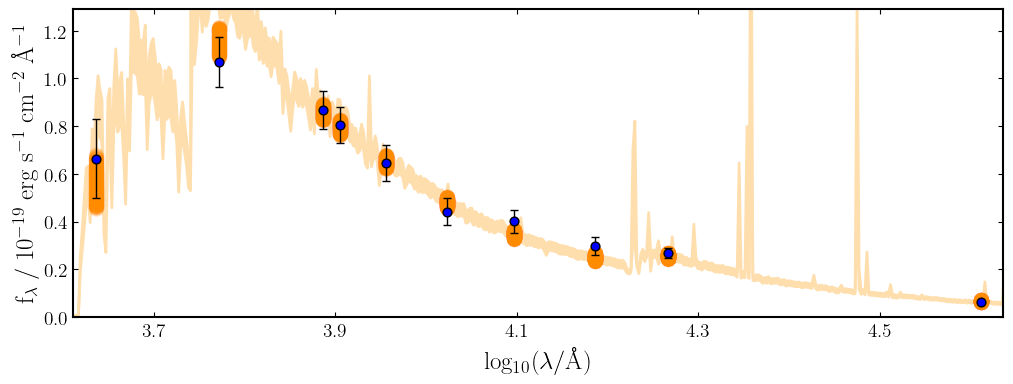

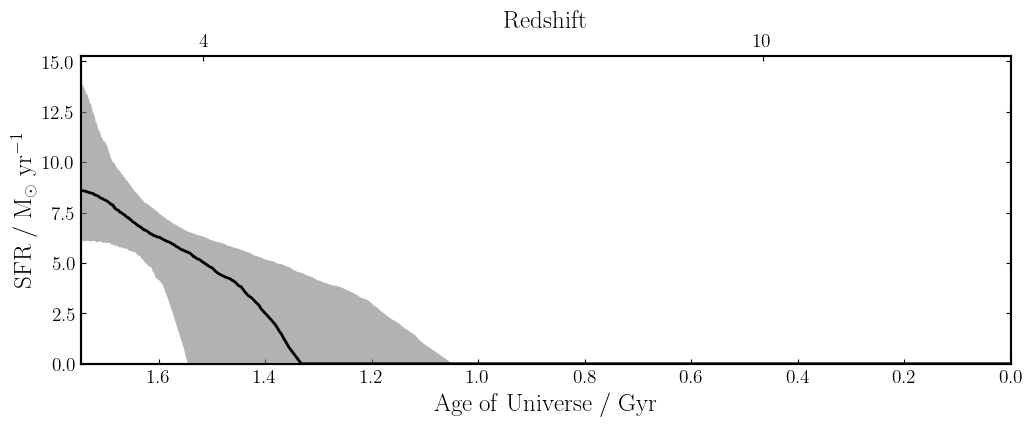

In [100]:
fig = fit.plot_spectrum_posterior(save=False, show=True)
fig = fit.plot_sfh_posterior(save=False, show=True)


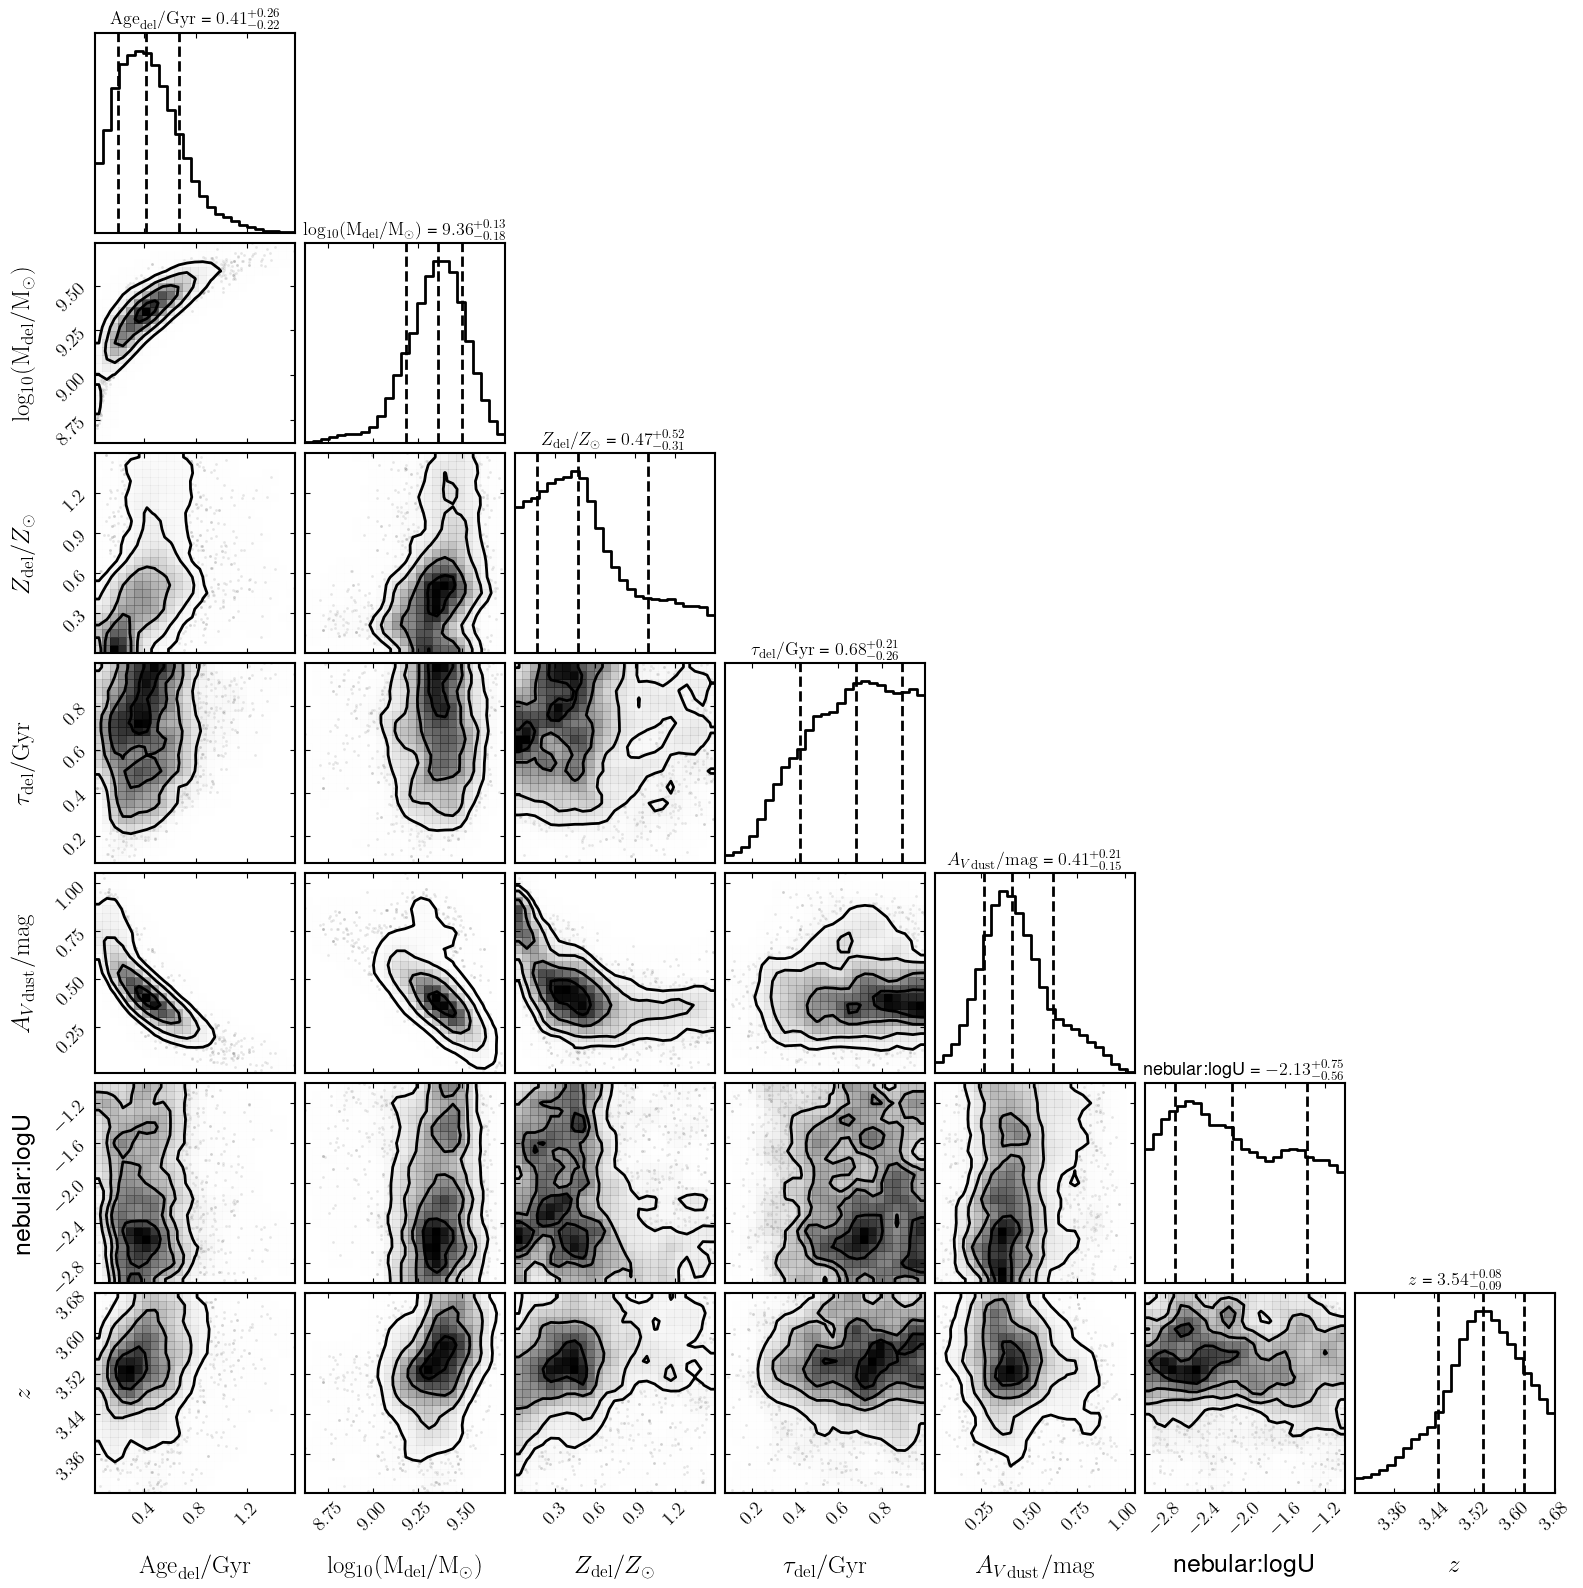

In [101]:
fig = fit.plot_corner(save=False, show=True)